## Derry Girls Subbreddit Sentiment Analysis

---------------

###### This project uses the information gained from the Reddit Scraper in this folder



In [ ]:
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

def analyze_sentiment(text):

    sid = SentimentIntensityAnalyzer()
    scores = sid.polarity_scores(text)
    compound_score = scores['compound']

    print(f"Text: '{text}'")
    print(f"Polarity Scores: {scores}")
    
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

for selftext in df_filtered['selftext'].dropna().head(5):
    print(f"Analyzing selftext: {selftext}")
    print(f"Sentiment: {analyze_sentiment(selftext)}\n")


C:\Users\finar\AppData\Local\Temp\ipykernel_49540\2447988156.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['sentiment'] = df_filtered['selftext'].apply(get_sentiment_label)


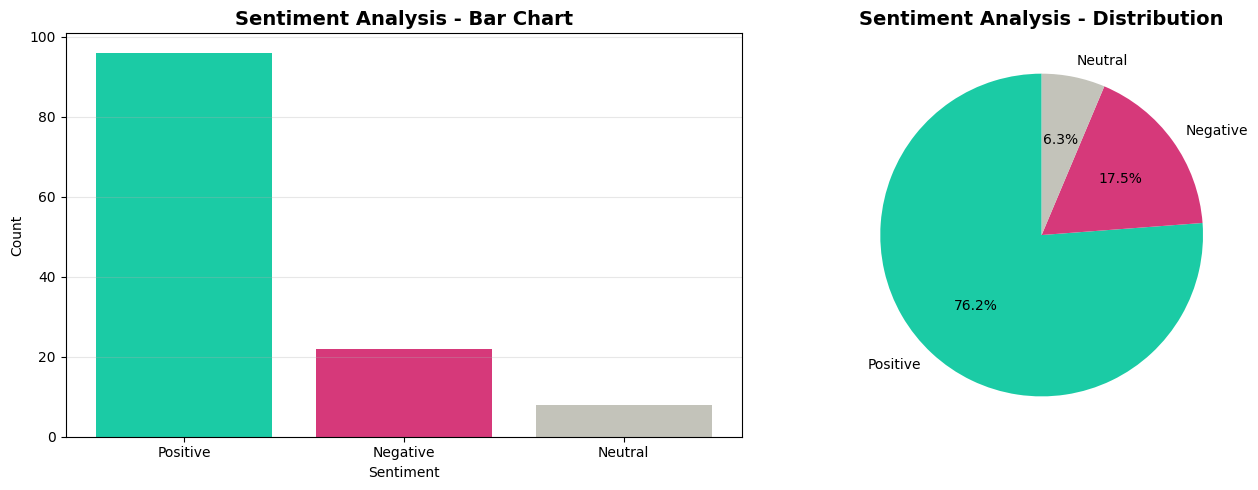


Sentiment Analysis Summary:
sentiment
Positive    96
Negative    22
Neutral      8
Name: count, dtype: int64

Total posts analyzed: 126


In [17]:
# Sentiment Analysis Chart

import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment analysis to filtered posts
def get_sentiment_label(text):
    if not isinstance(text, str) or len(text) == 0:
        return 'Neutral'
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to selftext
df_filtered['sentiment'] = df_filtered['selftext'].apply(get_sentiment_label)

# Count sentiments
sentiment_counts = df_filtered['sentiment'].value_counts()

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'Positive': "#1bcba5", 'Negative': "#d6397a", 'Neutral': "#c3c3ba"}
sentiment_colors = [colors.get(sentiment, "#c3c3ba") for sentiment in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors)
axes[0].set_title('Sentiment Analysis - Bar Chart', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
            colors=sentiment_colors, startangle=90)
axes[1].set_title('Sentiment Analysis - Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Sentiment_Analysis_Chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print(f"\nSentiment Analysis Summary:")
print(sentiment_counts)
print(f"\nTotal posts analyzed: {len(df_filtered)}")


C:\Users\finar\AppData\Local\Temp\ipykernel_49540\3716431432.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['sentiment'] = df_filtered['comment_body'].apply(get_sentiment_label)


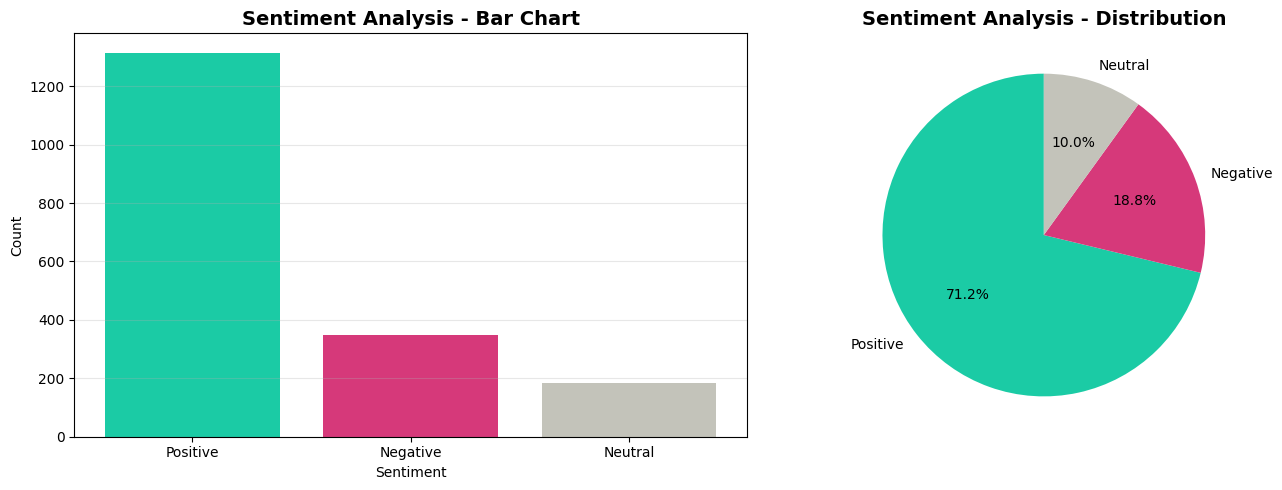


Sentiment Analysis Summary:
sentiment
Positive    1315
Negative     347
Neutral      184
Name: count, dtype: int64

Total posts analyzed: 1846


In [28]:
# Sentiment Analysis Chart

import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment analysis to filtered posts
def get_sentiment_label(text):
    if not isinstance(text, str) or len(text) == 0:
        return 'Neutral'
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to selftext
df_filtered['sentiment'] = df_filtered['comment_body'].apply(get_sentiment_label)

# Count sentiments
sentiment_counts = df_filtered['sentiment'].value_counts()

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = {'Positive': "#1bcba5", 'Negative': "#d6397a", 'Neutral': "#c3c3ba"}
sentiment_colors = [colors.get(sentiment, "#c3c3ba") for sentiment in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=sentiment_colors)
axes[0].set_title('Sentiment Analysis - Bar Chart', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
            colors=sentiment_colors, startangle=90)
axes[1].set_title('Sentiment Analysis - Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('Sentiment_Analysis_Chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print(f"\nSentiment Analysis Summary:")
print(sentiment_counts)
print(f"\nTotal posts analyzed: {len(df_filtered)}")
